# Reverse-DCF Monte Carlo Valuation — demo

Runs **fully offline** on synthetic financials (no API keys). Set `FMP_API_KEY` / `FRED_API_KEY` in a local `.env` to value a real company.

Pipeline: historical FCFF → reverse DCF (market-implied growth via Brent root-finding) → Monte Carlo over (WACC, terminal growth, margin) → fair-value distribution + P(undervalued) → WACC×g sensitivity grid.

In [1]:
%pip install -r ../requirements.txt -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: C:\Users\pilat\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
# ==== USER INPUTS ====
TICKER = "SYNTH"        # any real ticker if FMP_API_KEY is set; SYNTH = offline demo
WACC = 0.09             # central discount rate
G_TERM = 0.025          # central terminal growth
HORIZON = 10            # explicit DCF years
CENTRAL_GROWTH = 0.08   # analyst central-case near-term growth for the MC
N_DRAWS = 20_000        # Monte Carlo draws (>= 10k)
SEED = 42
# =====================

In [3]:
import sys
sys.path.insert(0, "../src")

import numpy as np
from data_loader import load_financials
from fcff import compute_fcff, base_inputs
from dcf import dcf_value, terminal_value_share
from reverse_dcf import implied_growth, repricing_error
from monte_carlo import MCAssumptions, run_monte_carlo, sensitivity_grid

company = load_financials(TICKER)
fcff_hist = compute_fcff(company.statements)
base = base_inputs(company.statements)
print(f"Market EV: {company.market_ev:,.0f} | base revenue: {base['revenue0']:,.0f} | median FCFF margin: {base['fcff_margin']:.1%}")
company.statements.round(0)

Market EV: 42,161 | base revenue: 17,651 | median FCFF margin: 12.0%


,revenue,ebit,tax_rate,dep_amort,capex,nwc
year,,,,,,
2018,10861.0,1953.0,0.0,501.0,579.0,1058.0
2019,11504.0,1973.0,0.0,485.0,617.0,1104.0
2020,12597.0,2378.0,0.0,600.0,720.0,1298.0
2021,13842.0,2599.0,0.0,621.0,782.0,1462.0
2022,14409.0,2603.0,0.0,640.0,816.0,1433.0
2023,15186.0,2905.0,0.0,652.0,861.0,1455.0
2024,16440.0,3036.0,0.0,800.0,1045.0,1576.0
2025,17651.0,3026.0,0.0,786.0,942.0,1823.0


## 1. Reverse DCF — what growth is the market already pricing?

In [4]:
g_implied = implied_growth(company.market_ev, base["revenue0"], WACC, G_TERM, base["fcff_margin"], HORIZON)
err = repricing_error(g_implied, company.market_ev, base["revenue0"], WACC, G_TERM, base["fcff_margin"], HORIZON)
tv_share = terminal_value_share(base["revenue0"], g_implied, WACC, G_TERM, base["fcff_margin"], HORIZON)
hist_g = company.statements["revenue"].pct_change().dropna()
print(f"Market-implied near-term growth: {g_implied:.2%}   (solver repricing error: {err:.2e})")
print(f"Historical revenue growth (mean): {hist_g.mean():.2%}")
print(f"Terminal value share of EV: {tv_share:.0%}  <- why point DCFs are fragile")

Market-implied near-term growth: 8.05%   (solver repricing error: 7.63e-14)
Historical revenue growth (mean): 7.20%
Terminal value share of EV: 56%  <- why point DCFs are fragile


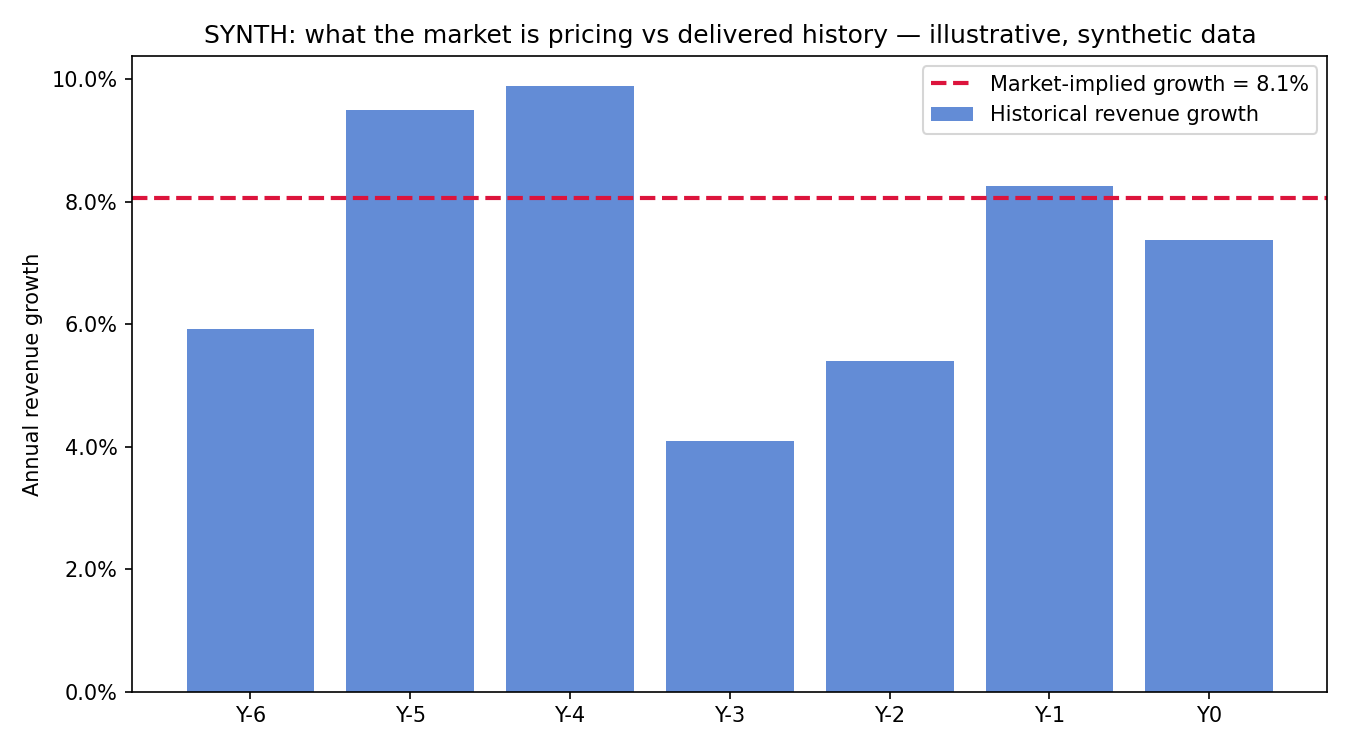

In [5]:
from plots import plot_implied_growth_context
from IPython.display import Image, display
p = plot_implied_growth_context(hist_g.to_numpy(), g_implied, company.ticker)
display(Image(str(p)))

## 2. Monte Carlo — fair-value *distribution*, not a point estimate

{'p5': '29,976', 'p25': '36,437', 'p50': '41,985', 'p75': '48,586', 'p95': '61,455'}
P(undervalued) = 49.2%


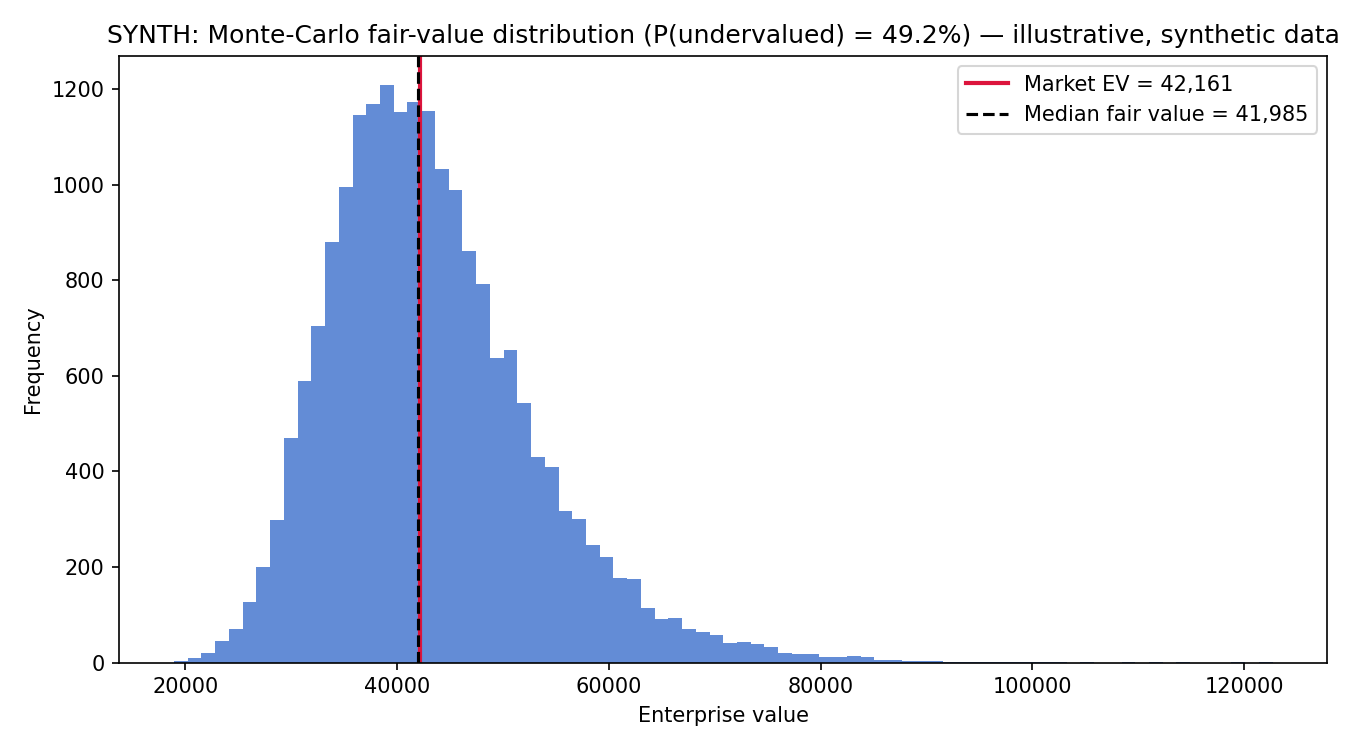

In [6]:
mc = run_monte_carlo(
    base["revenue0"], CENTRAL_GROWTH, company.market_ev,
    MCAssumptions(wacc_mean=WACC, g_term_mean=G_TERM, margin_mean=base["fcff_margin"]),
    n_draws=N_DRAWS, horizon=HORIZON, seed=SEED,
)
print({k: f"{v:,.0f}" for k, v in mc.quantiles.items()})
print(f"P(undervalued) = {mc.p_undervalued:.1%}")

from plots import plot_fair_value_distribution
p = plot_fair_value_distribution(mc, company.ticker)
display(Image(str(p)))

## 3. WACC × terminal-growth sensitivity grid

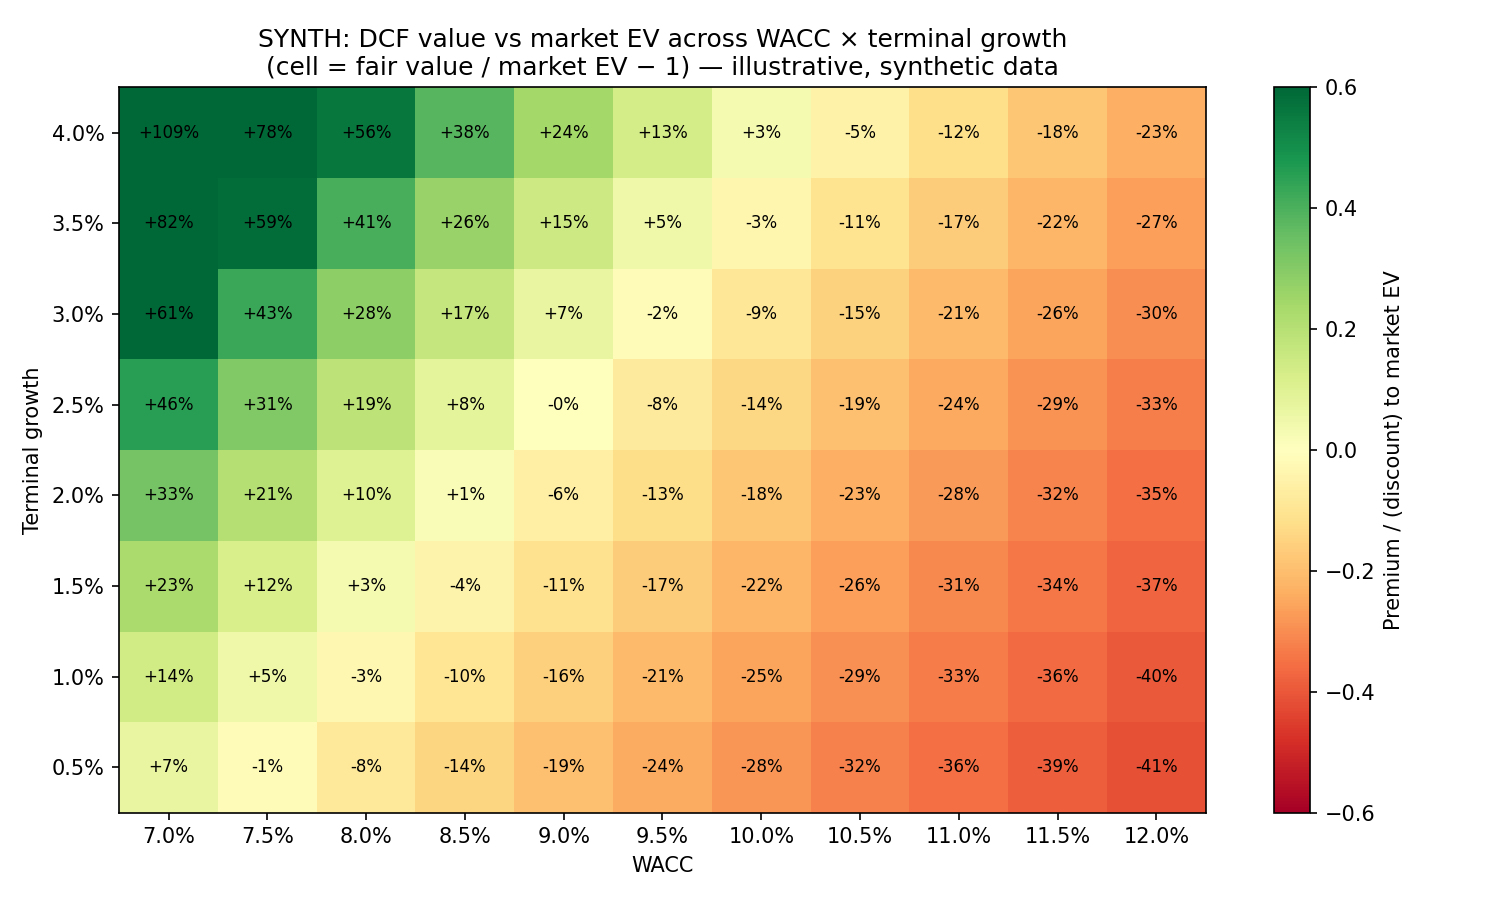

Value swing across the grid: 24,687 → 87,924  (+256%)


In [7]:
wacc_range = np.arange(0.07, 0.121, 0.005)
g_range = np.arange(0.005, 0.041, 0.005)
grid = sensitivity_grid(base["revenue0"], CENTRAL_GROWTH, base["fcff_margin"], wacc_range, g_range, HORIZON)

from plots import plot_sensitivity_heatmap
p = plot_sensitivity_heatmap(grid, wacc_range, g_range, company.market_ev, company.ticker)
display(Image(str(p)))

valid = grid[np.isfinite(grid)]
print(f"Value swing across the grid: {valid.min():,.0f} → {valid.max():,.0f}  ({valid.max()/valid.min()-1:+.0%})")